In [2]:
print("Set up complete and ready to go!")

Set up complete and ready to go!


In [3]:
import pandas as pd
import numpy as np  
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')   

In [4]:
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None) 

In [5]:
df =pd.read_csv('ESG_Data.csv',parse_dates=['Date'])

In [6]:
df.head()

,Date,Year,Asset_ID,Asset_Type,Location,Operational_Status,Energy_Type,Consumption_Units,Emission_Type,Emissions_tCO2e,Target_Emissions_tCO2e,Reduction_Percentage_vs_BaseYear
0,2020-01-01,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2357.044,Scope 1,0.645377,15004.345,0.0
1,2020-01-01,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2357.044,Scope 2,0.530871,15004.345,0.0
2,2020-01-02,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2440.574,Scope 1,0.688000,15004.345,0.0
3,2020-01-02,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2440.574,Scope 2,0.572372,15004.345,0.0
4,2020-01-03,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2396.825,Scope 1,0.715998,15004.345,0.0


In [7]:
df.tail()

,Date,Year,Asset_ID,Asset_Type,Location,Operational_Status,Energy_Type,Consumption_Units,Emission_Type,Emissions_tCO2e,Target_Emissions_tCO2e,Reduction_Percentage_vs_BaseYear
236731,2025-12-29,2025,A018,Depot,England,Active,DIESEL_L,220.770,Scope 2,0.140224,11307.747,24.64
236732,2025-12-30,2025,A018,Depot,England,Active,DIESEL_L,186.620,Scope 1,0.699935,11307.747,24.64
236733,2025-12-30,2025,A018,Depot,England,Active,DIESEL_L,186.620,Scope 2,0.149179,11307.747,24.64
236734,2025-12-31,2025,A018,Depot,England,Active,DIESEL_L,155.839,Scope 1,0.593795,11307.747,24.64
236735,2025-12-31,2025,A018,Depot,England,Active,DIESEL_L,155.839,Scope 2,0.138396,11307.747,24.64


DATA EXAMINATION


In [8]:
print(f"data shape: {df.shape}\n")
print(f"data columns: {df.columns}\n")
print(f"data info: {df.info()}\n")
print(f"data description: {df.describe()}\n")
print(f"data null values: {df.isnull().sum()}\n")
print(f"data duplicates: {df.duplicated().sum()}\n")
print(f"data date range: {df['Date'].min()} to {df['Date'].max()}")

data shape: (236736, 12)

data columns: Index(['Date', 'Year', 'Asset_ID', 'Asset_Type', 'Location',
       'Operational_Status', 'Energy_Type', 'Consumption_Units',
       'Emission_Type', 'Emissions_tCO2e', 'Target_Emissions_tCO2e',
       'Reduction_Percentage_vs_BaseYear'],
      dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 236736 entries, 0 to 236735
Data columns (total 12 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   Date                              236736 non-null  datetime64[us]
 1   Year                              236736 non-null  int64         
 2   Asset_ID                          236736 non-null  str           
 3   Asset_Type                        236736 non-null  str           
 4   Location                          236736 non-null  str           
 5   Operational_Status                236736 non-null  str           
 6   Energy_Type                 

Check for cardinality

In [9]:
for col in df.select_dtypes(include=['object']).columns:
    print(f"Unique values in {col}: {df[col].unique()}\n")

Unique values in Asset_ID: <StringArray>
['A001', 'A002', 'A003', 'A004', 'A005', 'A006', 'A007', 'A008', 'A009',
 'A010', 'A011', 'A012', 'A013', 'A014', 'A015', 'A016', 'A017', 'A018']
Length: 18, dtype: str

Unique values in Asset_Type: <StringArray>
['ServiceHub', 'Office', 'Depot', 'DataCentre', 'ControlRoom']
Length: 5, dtype: str

Unique values in Location: <StringArray>
['England', 'Wales', 'Scotland']
Length: 3, dtype: str

Unique values in Operational_Status: <StringArray>
['Active']
Length: 1, dtype: str

Unique values in Energy_Type: <StringArray>
['ELECTRICITY_KWH', 'GAS_KWH', 'DIESEL_L']
Length: 3, dtype: str

Unique values in Emission_Type: <StringArray>
['Scope 1', 'Scope 2']
Length: 2, dtype: str



## Exploring the numerical features of our data

In [10]:
df.columns

Index(['Date', 'Year', 'Asset_ID', 'Asset_Type', 'Location',
       'Operational_Status', 'Energy_Type', 'Consumption_Units',
       'Emission_Type', 'Emissions_tCO2e', 'Target_Emissions_tCO2e',
       'Reduction_Percentage_vs_BaseYear'],
      dtype='str')

In [11]:
numeric_cols = df[['Emissions_tCO2e','Consumption_Units']]

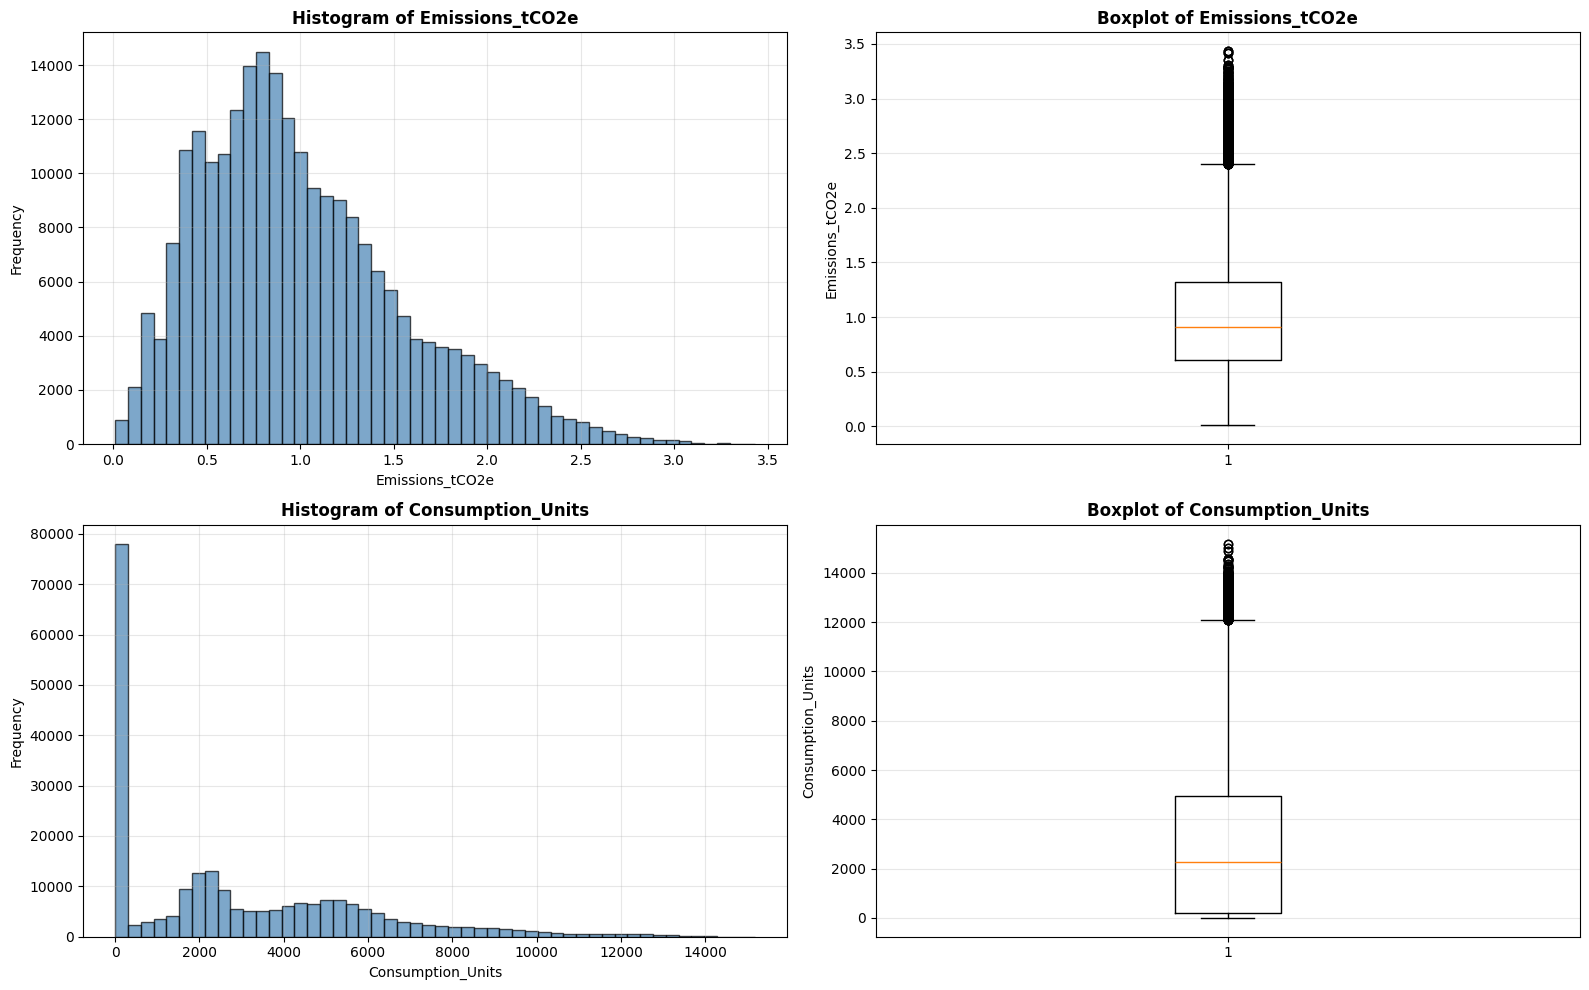

In [12]:
import matplotlib.pyplot as plt

#df.hist(bins=30, figsize=(15, 10))
#plt.tight_layout()
#plt.show()
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, col in enumerate(numeric_cols):
    #Histogram
    axes[idx,0].hist(df[col], bins=50, edgecolor = 'black',color='steelblue', alpha=0.7)
    axes[idx,0].set_title(f'Histogram of {col}', fontsize=12, fontweight='bold')
    axes[idx,0].set_xlabel(col)
    axes[idx,0].set_ylabel('Frequency')
    axes[idx,0].grid(True, alpha=0.3)
   
    #Boxplot
    axes[idx,1].boxplot(df[col], vert=True)
    axes[idx,1].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[idx,1].set_ylabel(col)
    axes[idx,1].grid(True, alpha=0.3)   
plt.tight_layout()
plt.show()

In [13]:

# Calculate  basic statistics
stats = pd.DataFrame({
    'Mean': numeric_cols.mean(),
    'Median': numeric_cols.median(),
    'Std_Deviation': numeric_cols.std(),
    'Skewness': numeric_cols.skew(),
    'Kurtosis': numeric_cols.kurtosis()
})

print(stats)

                          Mean       Median  Std_Deviation  Skewness  Kurtosis
Emissions_tCO2e       1.011650     0.906257       0.552706  0.812232  0.367291
Consumption_Units  2974.985016  2251.237000    2913.827113  0.972808  0.424688


In [14]:
df.columns

Index(['Date', 'Year', 'Asset_ID', 'Asset_Type', 'Location',
       'Operational_Status', 'Energy_Type', 'Consumption_Units',
       'Emission_Type', 'Emissions_tCO2e', 'Target_Emissions_tCO2e',
       'Reduction_Percentage_vs_BaseYear'],
      dtype='str')

## EDA Section

In [15]:
emmission_by_scope = df.groupby("Emission_Type")["Emissions_tCO2e"].sum()

Text(0.5, 1.0, 'Total Emissions by Scope')

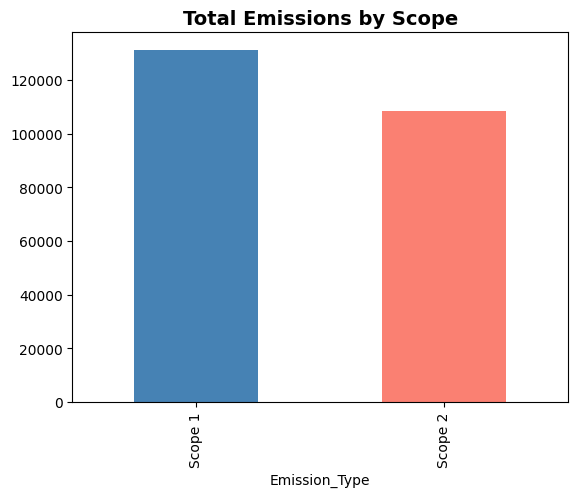

In [16]:
emmission_by_scope.plot(kind='bar', color=['steelblue', 'salmon', 'lightgreen'])
plt.title('Total Emissions by Scope', fontsize=14, fontweight='bold')   

In [17]:
daily_emmission_by_type = df.groupby(["Date", "Emission_Type"])["Emissions_tCO2e"].sum().reset_index()


In [18]:
print(daily_emmission_by_type.head())

        Date Emission_Type  Emissions_tCO2e
0 2020-01-01       Scope 1        54.483339
1 2020-01-01       Scope 2        65.017719
2 2020-01-02       Scope 1        59.236587
3 2020-01-02       Scope 2        64.950840
4 2020-01-03       Scope 1        59.415912


## Daily emmission trend

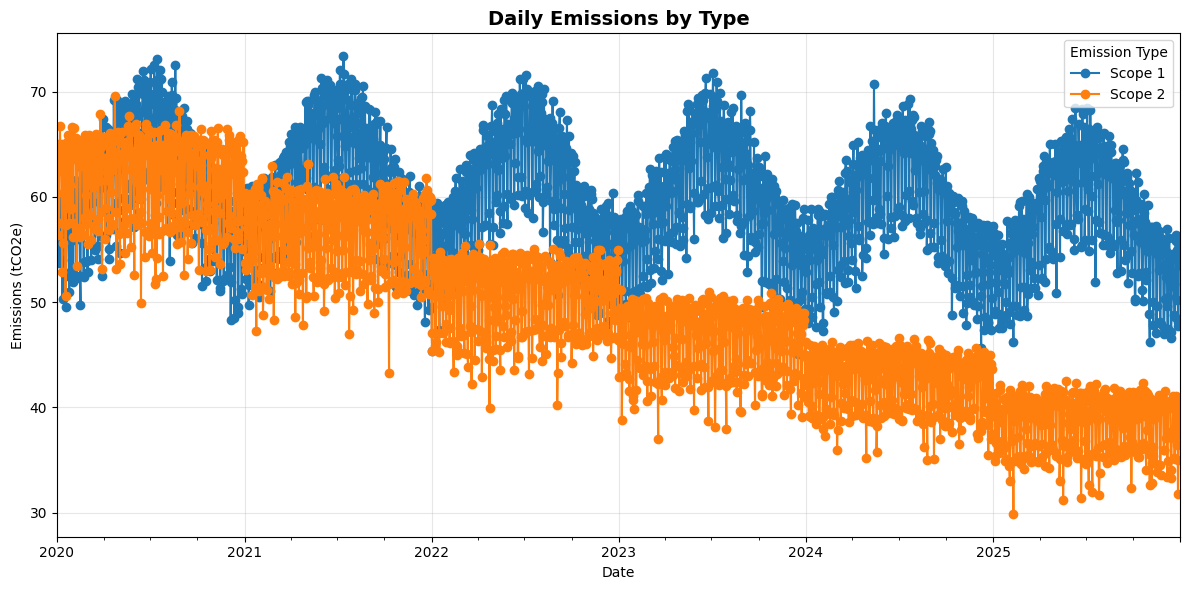

In [19]:
plot_data = daily_emmission_by_type.pivot(index='Date', columns='Emission_Type', values='Emissions_tCO2e')
plot_data.plot(figsize=(12, 6), marker='o')
plt.title('Daily Emissions by Type', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Emissions (tCO2e)') 
plt.grid(True, alpha=0.3)
plt.legend(title='Emission Type')
plt.tight_layout()
plt.show()

In [20]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_emmission_by_type = df.groupby(["Month", "Emission_Type"])["Emissions_tCO2e"].sum().reset_index()
monthly_emmission_by_type["Month"] = monthly_emmission_by_type["Month"].dt.to_timestamp()

In [21]:
# Extract the month's name in full and set it as a feature of the dataframe
df['Month_Name'] = df['Date'].dt.strftime('%B')
print(df[['Date', 'Month_Name']].head())

        Date Month_Name
0 2020-01-01    January
1 2020-01-01    January
2 2020-01-02    January
3 2020-01-02    January
4 2020-01-03    January


Text(0, 0.5, 'Emissions (tCO2e)')

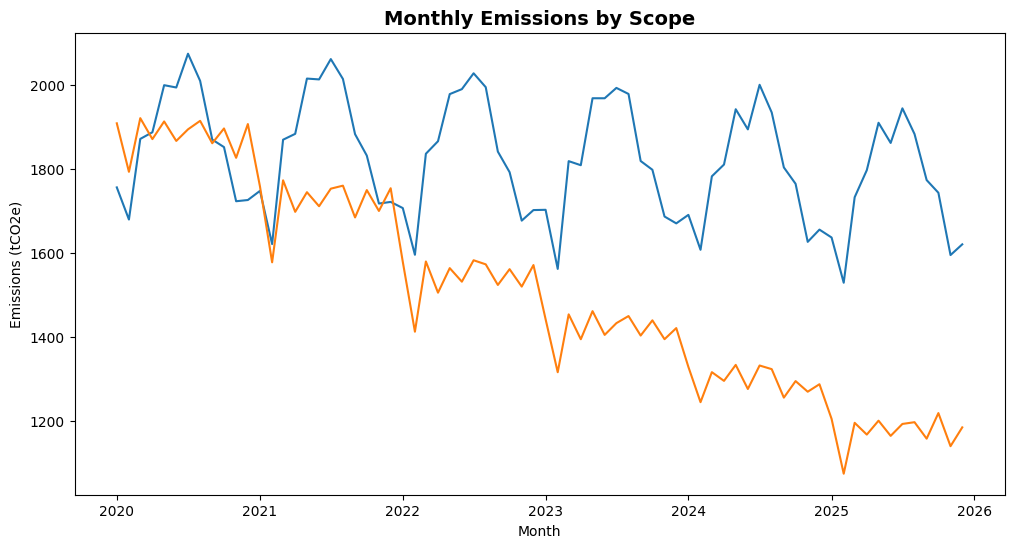

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
for scope in ['Scope 1','Scope 2']:
    scope_data = monthly_emmission_by_type[monthly_emmission_by_type['Emission_Type'] == scope]
    ax.plot(scope_data['Month'], scope_data['Emissions_tCO2e'], label=scope)
ax.set_title('Monthly Emissions by Scope', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Emissions (tCO2e)')



## Yearly emmission Vs yearly Target

In [23]:
# Group data by year and calculate yearly emissions and targets
yearly_data = df.groupby("Year").agg({
    "Emissions_tCO2e": 'sum',
    "Target_Emissions_tCO2e": 'first'
}).reset_index()

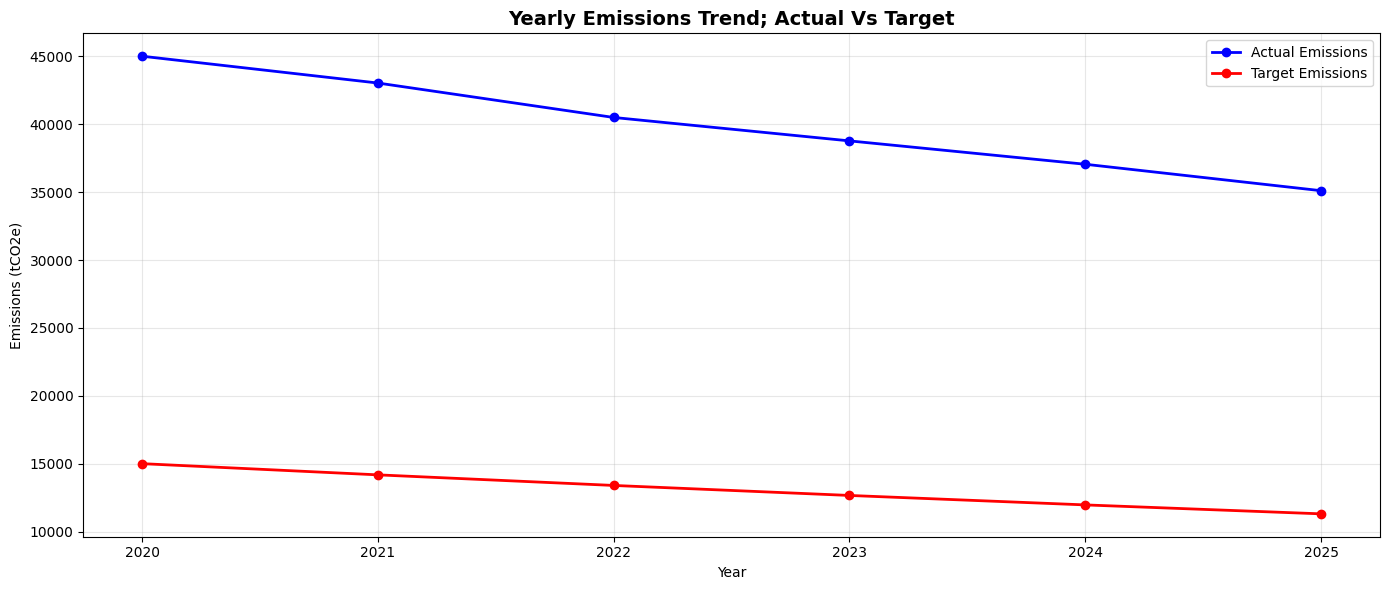

In [24]:
plt.figure(figsize=(14, 6))
plt.plot(yearly_data['Year'], yearly_data['Emissions_tCO2e'], marker='o', linewidth=2, label='Actual Emissions', color='blue')
plt.plot(yearly_data['Year'], yearly_data['Target_Emissions_tCO2e'], marker='o', linewidth=2, label='Target Emissions', color='red')
plt.title('Yearly Emissions Trend; Actual Vs Target', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Emissions (tCO2e)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Seasonality Analysis

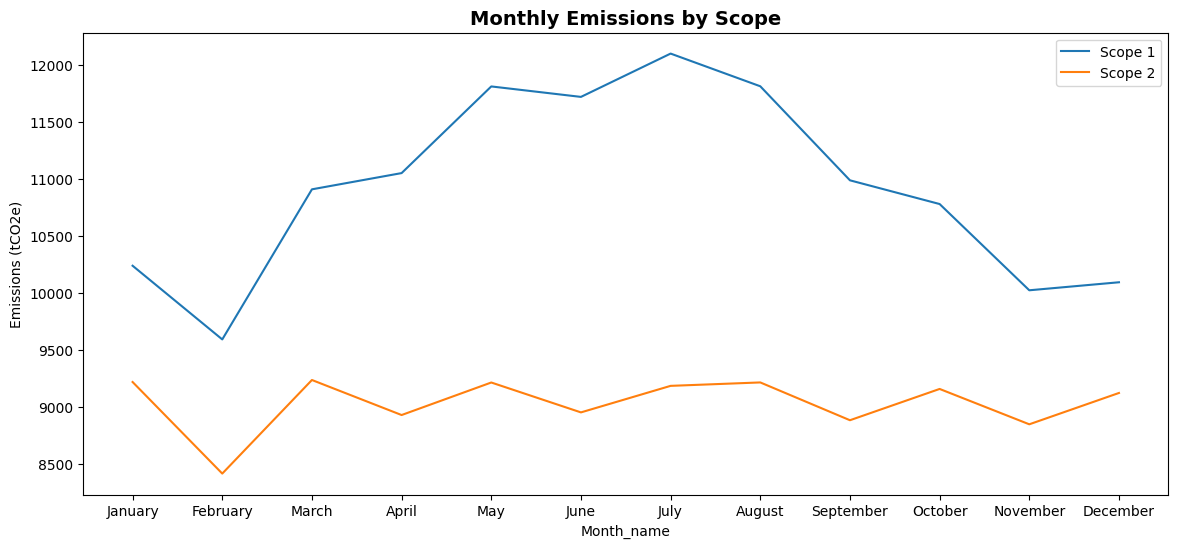

In [25]:
df['Month_Name'] = df['Date'].dt.month_name()
monthly_pattern = df.groupby(['Month_Name','Emission_Type'])['Emissions_tCO2e'].sum().reset_index()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_pattern['Month_Name'] = pd.Categorical(monthly_pattern['Month_Name'], categories=month_order, ordered=True)
monthly_pattern = monthly_pattern.sort_values('Month_Name')

#monthly_pattern 

fig, ax = plt.subplots(figsize=(14, 6))
for scope in ['Scope 1', 'Scope 2']:
    data = monthly_pattern[monthly_pattern['Emission_Type'] == scope]
    ax.plot(data['Month_Name'], data['Emissions_tCO2e'], label=scope)
    ax.set_title('Monthly Emissions by Scope', fontsize=14, fontweight='bold')
ax.set_xlabel('Month_name')
ax.set_ylabel('Emissions (tCO2e)')
ax.legend()

## Trainning a Base  model- Sarima and Arima Respectively
- Smoothing Techniques,
- Prophet
- Auto Arima

In [26]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [27]:
emission_data = df.groupby(['Date', 'Emission_Type'])['Emissions_tCO2e'].sum().reset_index()
emission_data_pivot = emission_data.sort_values('Date')

In [28]:
#Split data
split_date = emission_data['Date'].quantile(0.8)
split_date

Timestamp('2024-10-19 00:00:00')

In [ ]:
scope1_data = emission_data[emission_data['Emission_Type'] == 'Scope 1'].set_index('Date')['Emissions_tCO2e']
scope1_train = scope1_data[scope1_data.index <= split_date]
scope1_test = scope1_data[scope1_data.index > split_date]
print(scope1_train.tail())
print(scope1_test.head())

Date
2024-10-15    60.052584
2024-10-16    59.521971
2024-10-17    58.529901
2024-10-18    58.331160
2024-10-19    51.355305
Name: Emissions_tCO2e, dtype: float64
Date
2024-10-20    51.652524
2024-10-21    57.493557
2024-10-22    55.193703
2024-10-23    56.795454
2024-10-24    59.856975
Name: Emissions_tCO2e, dtype: float64


In [30]:
#Instantiate and fit SARIMA model for Scope 1 emissions
scope1_model = SARIMAX(scope1_train, order = (0, 0, 0), seasonal_order=(0, 0, 0, 365))
filted_scope1_model = scope1_model.fit()
scope1_pred = filted_scope1_model.forecast(steps = len(scope1_test))
print(r2_score(scope1_test, scope1_pred))
print(mean_squared_error(scope1_test, scope1_pred))
print(mean_absolute_error(scope1_test, scope1_pred))

c:\Users\unclesteve\Documents\NEXYGENE\Nexygen-Net-Zero-Project\NexyNetZero\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\unclesteve\Documents\NEXYGENE\Nexygen-Net-Zero-Project\NexyNetZero\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


-121.50060416453695
3278.2676742413996
57.02198205479452


In [31]:
scope2_data = emission_data[emission_data['Emission_Type'] == 'Scope 2'].set_index('Date')['Emissions_tCO2e']
scope2_train = scope2_data[scope2_data.index <= split_date]
scope2_test = scope2_data[scope2_data.index > split_date]
print(scope2_train.tail())
print(scope2_test.head())

Date
2024-10-15    44.275398
2024-10-16    44.300937
2024-10-17    43.856001
2024-10-18    44.211939
2024-10-19    39.227883
Name: Emissions_tCO2e, dtype: float64
Date
2024-10-20    39.613749
2024-10-21    44.947341
2024-10-22    40.490502
2024-10-23    43.761948
2024-10-24    45.425337
Name: Emissions_tCO2e, dtype: float64


In [32]:
#Instantiate and fit ARIMA model for Scope 2 emissions
scope2_model = ARIMA(scope2_train)
filted_scope2_model = scope2_model.fit()
scope2_pred = filted_scope2_model.forecast(steps = len(scope2_test))
print(r2_score(scope2_test, scope2_pred))
print(mean_squared_error(scope2_test, scope2_pred))
print(mean_absolute_error(scope2_test, scope2_pred))

c:\Users\unclesteve\Documents\NEXYGENE\Nexygen-Net-Zero-Project\NexyNetZero\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\unclesteve\Documents\NEXYGENE\Nexygen-Net-Zero-Project\NexyNetZero\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\unclesteve\Documents\NEXYGENE\Nexygen-Net-Zero-Project\NexyNetZero\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


-19.409339890438545
174.45985400495513
12.880675991298327


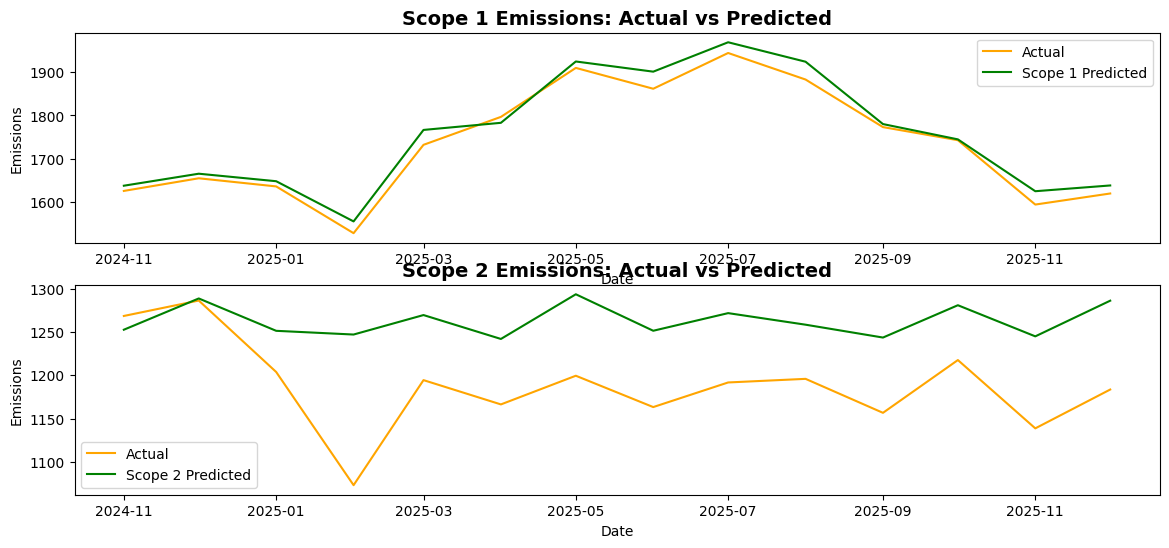

In [57]:
fig, ax = plt.subplots(2, 1,figsize=(14, 6))

ax[0].plot(scope1_test.index, scope1_test.values, label='Actual', color='orange')
ax[0].plot(scope1_test.index, scope1_pred, label='Scope 1 Predicted', color='green')
ax[0].set_title('Scope 1 Emissions: Actual vs Predicted', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Emissions')
ax[0].legend()  


ax[1].plot(scope2_test.index, scope2_test.values, label='Actual', color='orange')
ax[1].plot(scope2_test.index, scope2_pred, label='Scope 2 Predicted', color='green')
ax[1].set_title('Scope 2 Emissions: Actual vs Predicted', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Emissions')
ax[1].legend()

In [53]:
#Let's do some parameter  tuning to see if we can get a good model performance
from pmdarima  import auto_arima

model =  auto_arima(scope2_data,
                   seasonal =False,
                   #m=12,
                   start_p = 0, max_d= 5,
                   start_q = 0, max_q = 5,
                   start_P = 0, max_P = 2,
                   start_Q = 0, max_Q = 2,
                   information_criterion = 'aic' #akaike information criteria
                  )
print(model.order)
print(model.seasonal_order)

(0, 1, 1)
(0, 0, 0, 0)


### Introducing the hyper parameter for posssible better performance of the model with a weekly seasonality (m=7) 

In [ ]:
#Instantiate and fit SARIMA model for Scope 1 emissions
scope1_model = SARIMAX(scope1_train, order = (1, 1, 1), seasonal_order=(2, 0, 2, 7))
filted_scope1_model = scope1_model.fit()
scope1_pred = filted_scope1_model.forecast(steps = len(scope1_test))
print(r2_score(scope1_test, scope1_pred))
print(mean_squared_error(scope1_test, scope1_pred))
print(mean_absolute_error(scope1_test, scope1_pred))

c:\Users\unclesteve\Documents\NEXYGENE\Nexygen-Net-Zero-Project\NexyNetZero\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\unclesteve\Documents\NEXYGENE\Nexygen-Net-Zero-Project\NexyNetZero\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


0.3770850166700349
16.669975365251407
3.507384196642004


### Experimenting with Monthly emission data by scope to see if we can get better performance with the SARIMA model.

#### SARIMA with Scope 1 Monthly Data

In [36]:
### Starting with scope 1 monthly data

scope1_data = monthly_emmission_by_type[monthly_emmission_by_type['Emission_Type'] == 'Scope 1'].set_index('Month')['Emissions_tCO2e']
scope1_train = scope1_data[scope1_data.index <= split_date]
scope1_test = scope1_data[scope1_data.index > split_date]
print(scope1_train.tail())
print(scope1_test.head())

Month
2024-06-01    1894.113231
2024-07-01    2000.399088
2024-08-01    1934.350734
2024-09-01    1803.409461
2024-10-01    1764.327360
Name: Emissions_tCO2e, dtype: float64
Month
2024-11-01    1625.918904
2024-12-01    1655.106498
2025-01-01    1636.319493
2025-02-01    1528.405722
2025-03-01    1732.301748
Name: Emissions_tCO2e, dtype: float64


In [49]:
#Auto parameter tune and fit SARIMA model for Scope 1 emissions
scope1_model = SARIMAX(scope1_train, order = (3, 1, 2 ), seasonal_order=(2, 1, 0, 12))
filted_scope1_model = scope1_model.fit()
scope1_pred = filted_scope1_model.forecast(steps = len(scope1_test))
print(r2_score(scope1_test, scope1_pred))
print(mean_squared_error(scope1_test, scope1_pred))
print(mean_absolute_error(scope1_test, scope1_pred))

c:\Users\unclesteve\Documents\NEXYGENE\Nexygen-Net-Zero-Project\NexyNetZero\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\unclesteve\Documents\NEXYGENE\Nexygen-Net-Zero-Project\NexyNetZero\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


0.9641844122653707
566.2938181398729
20.583922100166042


#### 0.9641844122653707
#### 566.2938181398729
#### 20.583922100166042
#### is a sactisfactory result for Scope 1 model

#### ARIMA with Scope 2 Monthly Data

In [62]:
### experimenting with scope 2 monthly data

scope2_data = monthly_emmission_by_type[monthly_emmission_by_type['Emission_Type'] == 'Scope 2'].set_index('Month')['Emissions_tCO2e']
scope2_train = scope2_data[scope2_data.index <= split_date]
scope2_test = scope2_data[scope2_data.index > split_date]
print(scope2_train.tail())
print(scope2_test.head())

Month
2024-06-01    1275.122643
2024-07-01    1331.135727
2024-08-01    1322.439531
2024-09-01    1254.531420
2024-10-01    1293.959880
Name: Emissions_tCO2e, dtype: float64
Month
2024-11-01    1268.633373
2024-12-01    1286.464317
2025-01-01    1203.915963
2025-02-01    1073.108649
2025-03-01    1194.493203
Name: Emissions_tCO2e, dtype: float64


In [63]:
#Instantiate and fit ARIMA model for Scope 2 Monthly emissions Data
scope2_model = ARIMA(scope2_train, order = (5, 1, 4))
filted_scope2_model = scope2_model.fit()
scope2_pred = filted_scope2_model.forecast(steps = len(scope2_test))
print(r2_score(scope2_test, scope2_pred))
print(mean_squared_error(scope2_test, scope2_pred))
print(mean_absolute_error(scope2_test, scope2_pred))

c:\Users\unclesteve\Documents\NEXYGENE\Nexygen-Net-Zero-Project\NexyNetZero\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\unclesteve\Documents\NEXYGENE\Nexygen-Net-Zero-Project\NexyNetZero\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\unclesteve\Documents\NEXYGENE\Nexygen-Net-Zero-Project\NexyNetZero\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


-1.96476057833527
7470.173869295554
76.78916828992287


c:\Users\unclesteve\Documents\NEXYGENE\Nexygen-Net-Zero-Project\NexyNetZero\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#### Saving our models

In [64]:
filted_scope1_model.save('scope1_model.pkl')
filted_scope2_model.save('scope2_model.pkl')